# # Sensitivity Analysis for MCV1 Forecasts
# This notebook quantifies how much each input feature impacts the forecast via One-At-a-Time (OAT) perturbation.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Import core forecasting logic
import sys
sys.path.append('.')
from mcv1_forecast.core import train_model, recursive_forecast, COUNTRIES, TARGET

# ## Load Data and Train Base Model

In [22]:
df_raw = pd.read_csv("vaccine_data.csv")
future_demo_df = pd.read_csv("future_demographics.csv")

# Train baseline model
model, df_engineered, feature_cols, dummy_cols = train_model(df_raw)

# ## Sensitivity Analyzer

In [23]:
class SensitivityAnalyzer:
    def __init__(self, model, df_engineered, feature_cols, dummy_cols):
        self.model = model
        self.df_engineered = df_engineered
        self.feature_cols = feature_cols
        self.dummy_cols = dummy_cols
        
        # Demographic features we can perturb
        self.target_features = [
            "Births (thousands)",
            "Crude Birth Rate (births per 1,000 population)",
            "Infant Mortality Rate (infant deaths per 1,000 live births)",
            "Under-Five Mortality (deaths under age 5 per 1,000 live births)",
            "Net Number of Migrants (thousands)",
            "Net Migration Rate (per 1,000 population)",
            "Pop_Age_0(In Thousands)"
        ]

    def run_baseline(self, future_demo_df):
        pred = recursive_forecast(self.df_engineered, self.model, self.feature_cols, self.dummy_cols, 2025, TARGET, future_demo_df)
        return pred

    def one_at_a_time(self, country, future_demo_df, perturbation_pct=5):
        """OAT sensitivity analysis for a specific country."""
        baseline_pred = self.run_baseline(future_demo_df)
        country_baseline = baseline_pred[baseline_pred['Country'] == country].set_index('Year')['Predicted']
        
        results = []
        
        for feature in self.target_features:
            # High perturbation (+X%)
            demo_high = future_demo_df.copy()
            country_mask = demo_high['Country'] == country
            if feature in demo_high.columns:
                demo_high.loc[country_mask, feature] *= (1 + perturbation_pct / 100.0)
                pred_high = recursive_forecast(self.df_engineered, self.model, self.feature_cols, self.dummy_cols, 2025, TARGET, demo_high)
                val_high = pred_high[pred_high['Country'] == country].set_index('Year')['Predicted']
                
                # Low perturbation (-X%)
                demo_low = future_demo_df.copy()
                demo_low.loc[country_mask, feature] *= (1 - perturbation_pct / 100.0)
                pred_low = recursive_forecast(self.df_engineered, self.model, self.feature_cols, self.dummy_cols, 2025, TARGET, demo_low)
                val_low = pred_low[pred_low['Country'] == country].set_index('Year')['Predicted']
                
                for year in country_baseline.index:
                    base = country_baseline[year]
                    high = val_high[year]
                    low = val_low[year]
                    
                    # Absolute sensitivity
                    sens = (high - low) / 2.0
                    # Percentage impact on baseline forecast
                    impact_pct = ((high - base) / base) * 100 if base != 0 else 0
                    
                    results.append({
                        'Year': year,
                        'Feature': feature,
                        'Baseline': base,
                        'High': high,
                        'Low': low,
                        'Sensitivity': sens,
                        'Impact_Pct': impact_pct,
                        'Abs_Impact_Pct': abs(impact_pct)
                    })
                    
        return pd.DataFrame(results).sort_values(by='Abs_Impact_Pct', ascending=False)

    def elasticity_curve(self, country, feature, future_demo_df, pct_range=(-20, 20), steps=21):
        """Compute forecast elasticity for a single feature over a range."""
        baseline_pred = self.run_baseline(future_demo_df)
        country_baseline = baseline_pred[baseline_pred['Country'] == country].set_index('Year')['Predicted']
        
        pct_variations = np.linspace(pct_range[0], pct_range[1], steps)
        results = []
        
        for pct in pct_variations:
            demo_adj = future_demo_df.copy()
            country_mask = demo_adj['Country'] == country
            
            if feature in demo_adj.columns:
                demo_adj.loc[country_mask, feature] *= (1 + pct / 100.0)
                pred = recursive_forecast(self.df_engineered, self.model, self.feature_cols, self.dummy_cols, 2025, TARGET, demo_adj)
                val = pred[pred['Country'] == country].set_index('Year')['Predicted']
                
                for year in val.index:
                    results.append({
                        'Perturbation_Pct': pct,
                        'Year': year,
                        'Forecast': val[year],
                        '% Change': ((val[year] - country_baseline[year]) / country_baseline[year]) * 100
                    })
                    
        return pd.DataFrame(results)

# ## Run Analysis

In [24]:
analyzer = SensitivityAnalyzer(model, df_engineered, feature_cols, dummy_cols)

# Run OAT for a specific country (e.g., Kyrgyzstan)
country = COUNTRIES[0]
oat_results = analyzer.one_at_a_time(country, future_demo_df, perturbation_pct=10)

# ## Visualizations

In [25]:
def plot_tornado(oat_df, country, year):
    """Tornado diagram for a specific year."""
    data = oat_df[oat_df['Year'] == year].copy()
    data = data.sort_values(by='Abs_Impact_Pct', ascending=True) # Ascending for horizontal bar plot
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    y_pos = np.arange(len(data))
    
    # Impacts from +10% increase
    high_impacts = ((data['High'] - data['Baseline']) / data['Baseline']) * 100
    # Impacts from -10% decrease
    low_impacts = ((data['Low'] - data['Baseline']) / data['Baseline']) * 100
    
    ax.barh(y_pos, high_impacts, height=0.4, align='center', color='blue', label='+5% Perturbation')
    ax.barh(y_pos, low_impacts, height=0.4, align='edge', color='red', label='-5% Perturbation')
    
    ax.set_yticks(y_pos)
    # Wrap long feature names
    labels = [f.replace(' (', '\n(') for f in data['Feature']]
    ax.set_yticklabels(labels)
    ax.set_xlabel('% Change in MCV1 Forecast')
    ax.set_title(f"Sensitivity Tornado Diagram - {country} ({year})")
    
    # Add vertical line at 0
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    
    ax.legend()
    plt.tight_layout()
    plt.show()

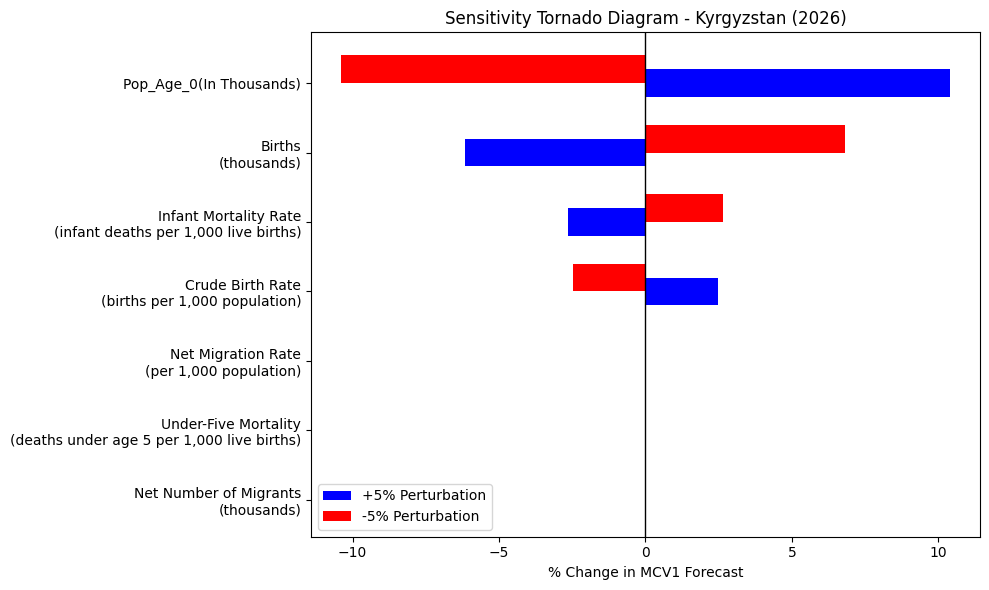

In [26]:
plot_tornado(oat_results, country, year=2026)

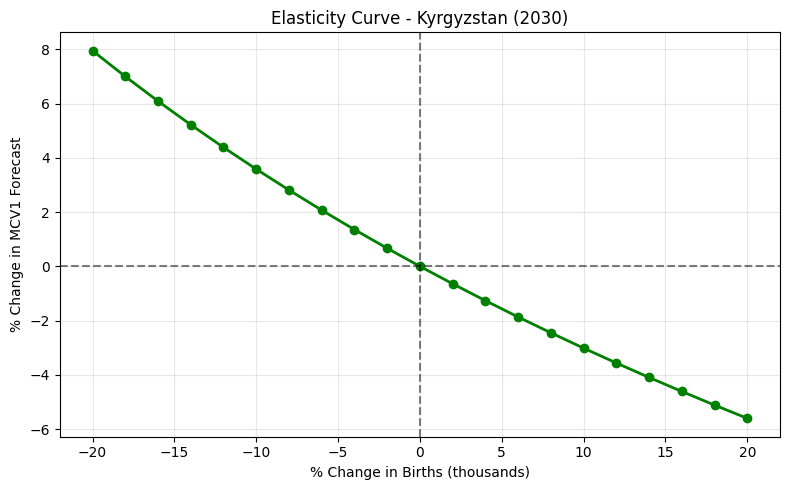

In [27]:
# Elasticity Analysis
feature_to_test = "Births (thousands)"
elasticity_df = analyzer.elasticity_curve(country, feature_to_test, future_demo_df)

# Plot elasticity for 2030
elast_2030 = elasticity_df[elasticity_df['Year'] == 2030]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(elast_2030['Perturbation_Pct'], elast_2030['% Change'], 'go-', linewidth=2)
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel(f"% Change in {feature_to_test}")
ax.set_ylabel("% Change in MCV1 Forecast")
ax.set_title(f"Elasticity Curve - {country} (2030)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()